# K-Nearest Neighbors (KNN) from Scratch

## Objectives
- Understand how the KNN algorithm works.
- Implement KNN classification using NumPy.
- Evaluate the model using classification metrics.
- Compare the implementation with Scikit-Learn.

KNN is a supervised learning algorithm that classifies a data point
based on the majority class among its K nearest neighbors.

## Mathematical Intuition

KNN uses Euclidean distance to measure similarity:

d(x, xᵢ) = √Σ(xⱼ - xᵢⱼ)²

Steps:
1. Calculate the distance between the test point and training points.
2. Select the K closest training points.
3. Count the class labels of these neighbors.
4. Assign the majority class to the test point.

KNN is a lazy learning algorithm because it does not learn explicit
parameters during training.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier

## Generate a Classification Dataset

We will create a synthetic binary classification dataset with
two features so that the decision boundary can be visualized.

In [2]:
X, y = make_classification(
    n_samples=400,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    class_sep=1.5,
    random_state=42
)

df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df["Target"] = y

df.head()

,Feature_1,Feature_2,Target
0,1.300646,1.642262,1
1,-2.111599,-0.910046,0
2,1.610764,0.470789,1
3,-0.786785,-2.230777,0
4,-0.773271,3.589116,0


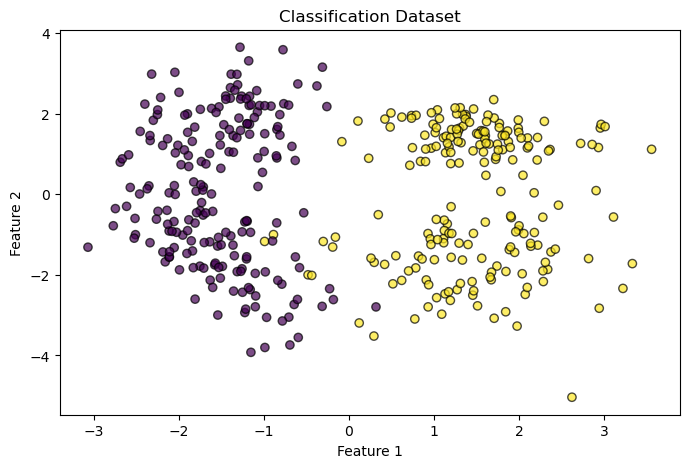

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification Dataset")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 320
Testing samples: 80


## KNN Implementation from Scratch

The implementation will:
- Calculate Euclidean distances.
- Select the K nearest neighbors.
- Use majority voting for classification.|

In [5]:
class KNNScratch:
    def __init__(self, k=5):
        if k < 1:
            raise ValueError("k must be at least 1")
        
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)

        if self.k > len(self.X_train):
            raise ValueError("k cannot exceed the number of training samples")

        return self

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        X = np.asarray(X)
        predictions = []

        for sample in X:
            distances = [
                self._euclidean_distance(sample, train_sample)
                for train_sample in self.X_train
            ]

            nearest_indices = np.argsort(distances)[:self.k]
            nearest_labels = self.y_train[nearest_indices]

            most_common = Counter(nearest_labels).most_common(1)[0][0]
            predictions.append(most_common)

        return np.array(predictions)

In [6]:
knn = KNNScratch(k=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Predictions:", y_pred[:10])

Predictions: [0 0 1 0 0 0 0 0 0 1]


In [7]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0)
}

pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Score"]
)

,Metric,Score
0,Accuracy,0.975000
1,Precision,1.000000
2,Recall,0.950000
3,F1-Score,0.974359


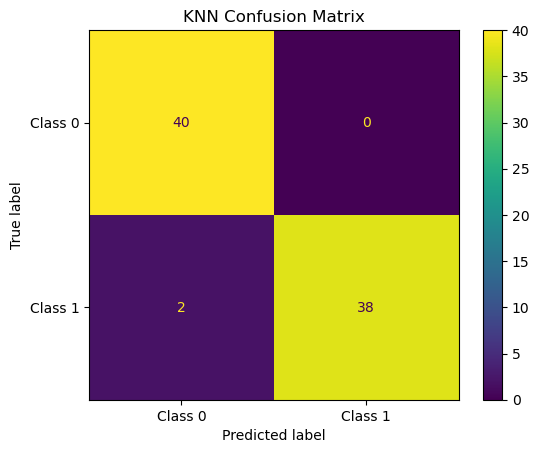

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

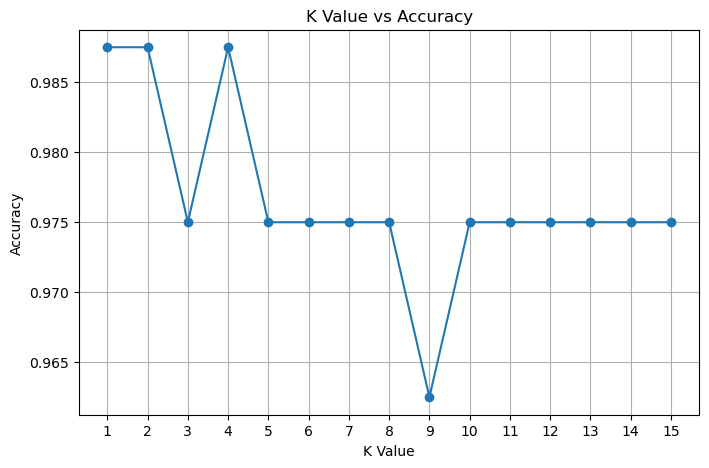

In [9]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNNScratch(k=k)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, predictions))

plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [10]:
best_k = k_values[np.argmax(accuracies)]

print("Best K based on test accuracy:", best_k)
print("Best accuracy:", max(accuracies))

Best K based on test accuracy: 1
Best accuracy: 0.9875


In [11]:
sklearn_knn = KNeighborsClassifier(n_neighbors=5)

sklearn_knn.fit(X_train_scaled, y_train)

sklearn_pred = sklearn_knn.predict(X_test_scaled)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "KNN From Scratch": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ],
    "Scikit-Learn KNN": [
        accuracy_score(y_test, sklearn_pred),
        precision_score(y_test, sklearn_pred, zero_division=0),
        recall_score(y_test, sklearn_pred, zero_division=0),
        f1_score(y_test, sklearn_pred, zero_division=0)
    ]
})

comparison

,Metric,KNN From Scratch,Scikit-Learn KNN
0,Accuracy,0.975000,0.975000
1,Precision,1.000000,1.000000
2,Recall,0.950000,0.950000
3,F1-Score,0.974359,0.974359


## Conclusion

- KNN classifies samples using the labels of nearby data points.
- Feature scaling is important because KNN relies on distance.
- The value of K significantly affects model performance.
- Small K values may be sensitive to noise.
- Large K values may lead to underfitting.
- The implementation from scratch produces results comparable
  to Scikit-Learn for this dataset.

## Limitations
- Prediction can be computationally expensive for large datasets.
- KNN requires storing the complete training dataset.
- Performance depends on the distance metric and K value.